# DefectVision — 02 EDA & Dataset Analysis

This notebook performs exploratory analysis of the verified MVTecAD-SEG dataset.

**Goals**
- Build an image-level metadata table
- Analyze image and mask properties
- Quantify defect size and complexity
- Compare train/validation/test distributions
- Visualize representative defects
- Check split overlap
- Save metadata for later modeling


## 1. Imports and paths


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"
IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"
LIST_ROOT = DATA_ROOT / "list"

print("Dataset:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())


Dataset: C:\Documents\DefectVision\data\raw\MVTecAD-SEG
Exists: True


## 2. Helper functions


In [2]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def get_files(folder):
    return sorted(
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

def read_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def read_mask(path):
    return np.array(Image.open(path).convert("L"))

def connected_components(binary):
    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    components = []
    neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    ys, xs = np.where(binary)

    for sy, sx in zip(ys, xs):
        if visited[sy, sx]:
            continue

        stack = [(int(sy), int(sx))]
        visited[sy, sx] = True
        count = 0
        min_y = max_y = int(sy)
        min_x = max_x = int(sx)

        while stack:
            y, x = stack.pop()
            count += 1
            min_y, max_y = min(min_y, y), max(max_y, y)
            min_x, max_x = min(min_x, x), max(max_x, x)

            for dy, dx in neighbors:
                ny, nx = y + dy, x + dx
                if (
                    0 <= ny < h and 0 <= nx < w
                    and binary[ny, nx]
                    and not visited[ny, nx]
                ):
                    visited[ny, nx] = True
                    stack.append((ny, nx))

        components.append((count, min_y, max_y, min_x, max_x))

    return components


## 3. Build the image-level metadata table


In [3]:
records = []

for split in ["train", "val", "test"]:
    img_dir = IMG_ROOT / split
    ann_dir = ANN_ROOT / split

    for img_path in get_files(img_dir):
        ann_path = ann_dir / img_path.name

        image = read_rgb(img_path)
        mask = read_mask(ann_path)
        binary = mask != 0

        defect_pixels = int(binary.sum())
        total_pixels = int(binary.size)
        defect_fraction = defect_pixels / total_pixels

        components = connected_components(binary)
        areas = [c[0] for c in components]

        ys, xs = np.where(binary)
        if len(xs):
            bbox_width = int(xs.max() - xs.min() + 1)
            bbox_height = int(ys.max() - ys.min() + 1)
        else:
            bbox_width = bbox_height = 0

        records.append({
            "split": split,
            "image_id": img_path.stem,
            "image_path": str(img_path),
            "annotation_path": str(ann_path),
            "height": image.shape[0],
            "width": image.shape[1],
            "channels": image.shape[2],
            "defect_pixels": defect_pixels,
            "defect_fraction": defect_fraction,
            "num_components": len(components),
            "largest_component_pixels": max(areas, default=0),
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
        })

df = pd.DataFrame(records)

print("Total images:", len(df))
df.head()


Total images: 1258


,split,image_id,image_path,annotation_path,height,width,channels,defect_pixels,defect_fraction,num_components,largest_component_pixels,bbox_width,bbox_height
0,train,0,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,256,256,3,7131,0.108810,1,7131,119,152
1,train,1,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,256,256,3,6192,0.094482,1,6192,173,107
2,train,10,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,256,256,3,7291,0.111252,1,7291,110,170
3,train,100,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,256,256,3,1908,0.029114,1,1908,68,65
4,train,1000,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,256,256,3,5310,0.081024,1,5310,84,87


## 4. Basic dataset statistics


In [4]:
print("Images per split:")
display(df.groupby("split").size().rename("images").to_frame())

print("\nImage dimensions:")
display(
    df.groupby(["height", "width", "channels"])
      .size()
      .reset_index(name="count")
)

print("\nDefect fraction summary:")
display(
    df.groupby("split")["defect_fraction"]
      .describe()
      .round(6)
)


Images per split:


,images
split,
test,253
train,880
val,125



Image dimensions:


,height,width,channels,count
0,256,256,3,1258



Defect fraction summary:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,253.0,0.045489,0.090715,0.000504,0.004761,0.014740,0.039642,0.486923
train,880.0,0.042821,0.085983,0.000427,0.005016,0.015488,0.036850,0.492401
val,125.0,0.048037,0.090989,0.000671,0.005402,0.017807,0.048920,0.480774


## 5. Defect-area distribution


In [ ]:
plt.figure(figsize=(9, 5))

for split in ["train", "val", "test"]:
    values = df.loc[df["split"] == split, "defect_fraction"]
    plt.hist(values, bins=40, alpha=0.45, label=split)

plt.xlabel("Defect pixels / total pixels")
plt.ylabel("Number of images")
plt.title("Defect-area distribution by split")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Small, medium and large defects


In [5]:
q1, q2 = df["defect_fraction"].quantile([1/3, 2/3])

def size_group(x):
    if x <= q1:
        return "small"
    if x <= q2:
        return "medium"
    return "large"

df["defect_size_group"] = df["defect_fraction"].apply(size_group)

print("Thresholds:")
print("Small/medium:", q1)
print("Medium/large:", q2)

display(df["defect_size_group"].value_counts().rename("images").to_frame())


Thresholds:
Small/medium: 0.0072784423828125
Medium/large: 0.0278472900390625


,images
defect_size_group,
small,421
large,419
medium,418


## 7. Defect-region complexity


Connected defect-region statistics:


,num_components
count,1258.000000
mean,1.499205
std,1.269713
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


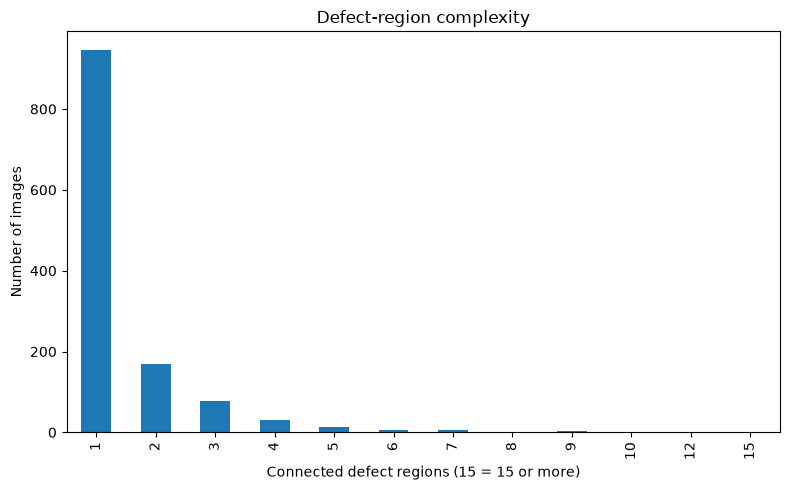

In [6]:
print("Connected defect-region statistics:")
display(df["num_components"].describe().to_frame())

plt.figure(figsize=(8, 5))
df["num_components"].clip(upper=15).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Connected defect regions (15 = 15 or more)")
plt.ylabel("Number of images")
plt.title("Defect-region complexity")
plt.tight_layout()
plt.show()


## 8. Compare train / validation / test


In [7]:
distribution = (
    df.groupby("split")
      .agg(
          images=("image_id", "count"),
          mean_defect_fraction=("defect_fraction", "mean"),
          median_defect_fraction=("defect_fraction", "median"),
          mean_components=("num_components", "mean"),
          mean_largest_component=("largest_component_pixels", "mean"),
      )
      .round(6)
)

display(distribution)


,images,mean_defect_fraction,median_defect_fraction,mean_components,mean_largest_component
split,,,,,
test,253,0.045489,0.014740,1.399209,2844.094862
train,880,0.042821,0.015488,1.517045,2670.759091
val,125,0.048037,0.017807,1.576000,2862.560000


## 9. Check for duplicate image IDs across splits


In [8]:
split_sets = {
    split: set(df.loc[df["split"] == split, "image_id"])
    for split in ["train", "val", "test"]
}

for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    overlap = split_sets[a] & split_sets[b]
    print(f"{a} ∩ {b}: {len(overlap)} overlapping IDs")
    if overlap:
        print("Examples:", sorted(overlap)[:10])


train ∩ val: 0 overlapping IDs
train ∩ test: 0 overlapping IDs
val ∩ test: 0 overlapping IDs


## 10. Visualize representative defects


--- SMALL DEFECT ---


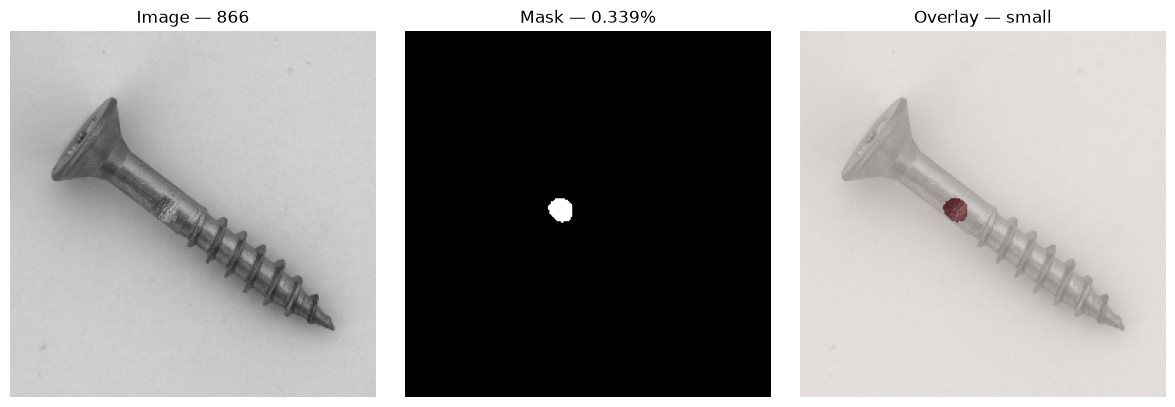

--- MEDIUM DEFECT ---


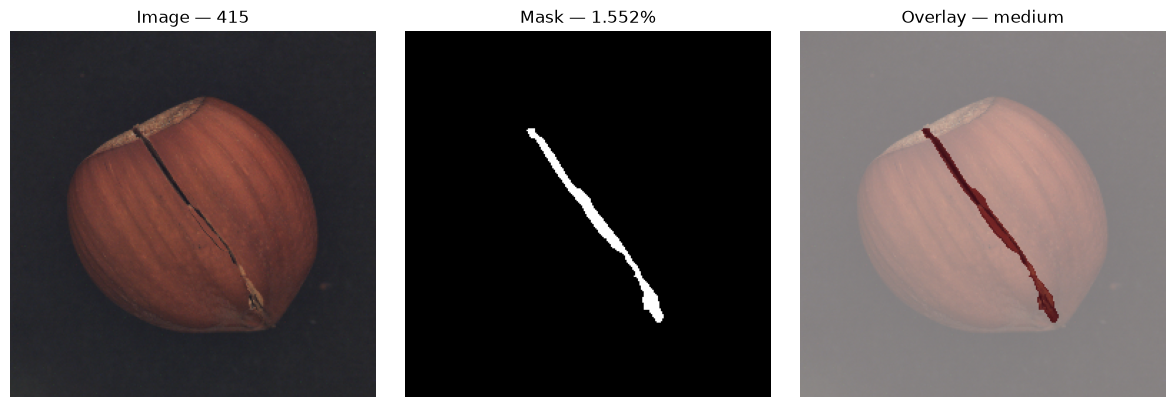

--- LARGE DEFECT ---


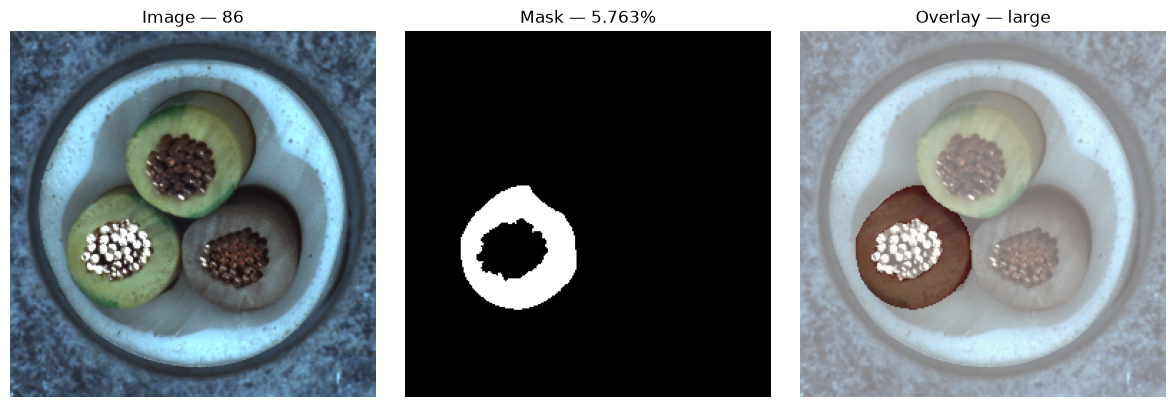

In [9]:
def show_record(row):
    image = read_rgb(Path(row["image_path"]))
    mask = read_mask(Path(row["annotation_path"]))
    binary = mask != 0

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(image)
    ax[0].set_title(f"Image — {row['image_id']}")
    ax[0].axis("off")

    ax[1].imshow(binary, cmap="gray")
    ax[1].set_title(f"Mask — {row['defect_fraction']:.3%}")
    ax[1].axis("off")

    ax[2].imshow(image)
    ax[2].imshow(binary, cmap="Reds", alpha=0.45)
    ax[2].set_title(f"Overlay — {row['defect_size_group']}")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

for group in ["small", "medium", "large"]:
    subset = df[df["defect_size_group"] == group].sort_values("defect_fraction")

    if len(subset):
        row = subset.iloc[len(subset) // 2]
        print(f"--- {group.upper()} DEFECT ---")
        show_record(row)


## 11. Inspect the official split lists


In [10]:
for split in ["train", "val", "test"]:
    path = LIST_ROOT / f"{split}.txt"
    lines = [
        x.strip()
        for x in path.read_text(encoding="utf-8").splitlines()
        if x.strip()
    ]

    print(f"{split}: {len(lines)} IDs")
    print("First 10:", lines[:10])
    print()


train: 880 IDs
First 10: ['310', '445', '57', '343', '450', '1215', '220', '794', '213', '1090']

val: 125 IDs
First 10: ['761', '1006', '1157', '460', '878', '1147', '826', '522', '1080', '1154']

test: 253 IDs
First 10: ['148', '132', '646', '917', '814', '277', '189', '455', '549', '1213']



## 12. Save metadata


In [11]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

metadata_path = processed_dir / "image_metadata.csv"
df.to_csv(metadata_path, index=False)

print("Saved:", metadata_path)


Saved: C:\Documents\DefectVision\data\processed\image_metadata.csv


## 13. EDA conclusions

After running all cells, record the actual findings:

- Total images: **from output**
- Image dimensions: **from output**
- Mean/median defect area: **from output**
- Small/medium/large defect distribution: **from output**
- Average number of defect regions: **from output**
- Train/validation/test comparability: **from output**
- Duplicate IDs across splits: **from output**
- Important visual observations: **from output**

These findings will determine our preprocessing and model strategy.
